<a href="https://colab.research.google.com/github/kyuho11488/kyuho11488/blob/main/%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D%EC%8B%A4%EC%8A%B5_9%EC%A3%BC%EC%B0%A8_%EA%B3%BC%EC%A0%9C_2021148025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# 라이브러리 코드

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [4]:
# 데이터 로드

train_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train.csv')
print(train_df)

test_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/test.csv')
print(test_df)

submission_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/sample_submission.csv')
print(submission_df)

       label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0          1       0       0       0       0       0       0       0       0   
1          0       0       0       0       0       0       0       0       0   
2          1       0       0       0       0       0       0       0       0   
3          4       0       0       0       0       0       0       0       0   
4          0       0       0       0       0       0       0       0       0   
...      ...     ...     ...     ...     ...     ...     ...     ...     ...   
41995      0       0       0       0       0       0       0       0       0   
41996      1       0       0       0       0       0       0       0       0   
41997      7       0       0       0       0       0       0       0       0   
41998      6       0       0       0       0       0       0       0       0   
41999      9       0       0       0       0       0       0       0       0   

       pixel8  ...  pixel774  pixel775 

In [5]:
# 입력(x), 정답(y) 분리

X = train_df.iloc[:, 1:].values
print(X)

y = train_df.iloc[:, 0].values
print(y)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[1 0 1 ... 7 6 9]


In [6]:
# 학습 / 검증 데이터 분리 (8:2)

x_train, x_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(f"x_train : {x_train.shape}, y_train : {y_train.shape}")
print(f"x_val : {x_val.shape}, y_val : {y_val.shape}")

x_train : (33600, 784), y_train : (33600,)
x_val : (8400, 784), y_val : (8400,)


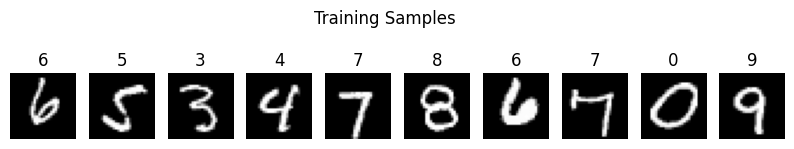

In [7]:
# 이미지 샘플 시각화하기

plt.figure(figsize= (10, 2))
for i in range(10):
  plt.subplot(1, 10, i + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap = "gray")
  plt.title(y_train[i])
  plt.axis('off')
plt.suptitle("Training Samples")
plt.show()

In [8]:
# 모델 학습하기

model = RandomForestClassifier(n_estimators = 100, random_state = 42)
model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [10]:
# 검증 데이터 예측 및 정확도 평가하기

y_val_pred = model.predict(x_val)
val_acc = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy : {val_acc : .4f}")

Validation Accuracy :  0.9629


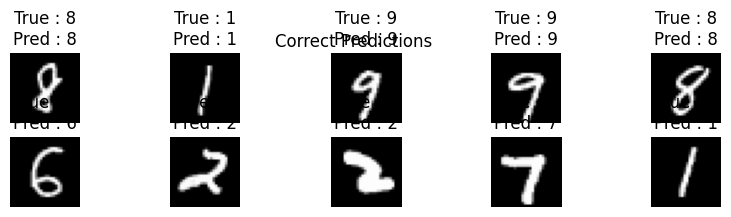

In [11]:
# 올바르게 분류된 이미지 시각화하기

correct_idx = np.where(y_val == y_val_pred)[0]
plt.figure(figsize = (10, 2))
for i, idx in enumerate(correct_idx[:10]):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_val[idx].reshape(28, 28), cmap = "gray")
  plt.title(f"True : {y_val[idx]}\nPred : {y_val_pred[idx]}")
  plt.axis('off')
plt.suptitle("Correct Predictions")
plt.show()

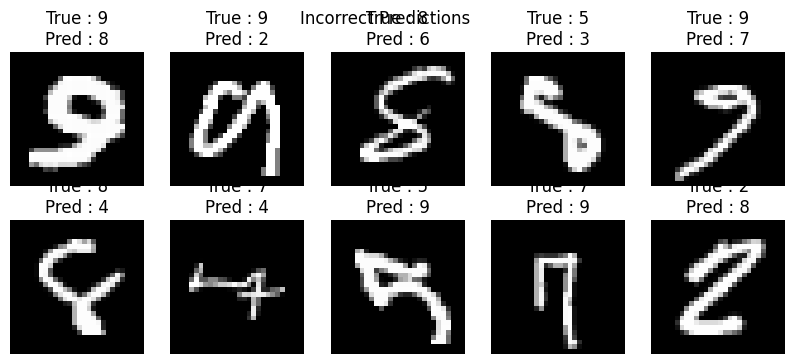

In [12]:
# 잘못 분류된 이미지 시각화하기

incorrect_idx = np.where(y_val != y_val_pred)[0]
plt.figure(figsize = (10, 4))
for i, idx in enumerate(incorrect_idx[:10]):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_val[idx].reshape(28, 28), cmap = "gray")
  plt.title(f"True : {y_val[idx]}\nPred : {y_val_pred[idx]}")
  plt.axis('off')
plt.suptitle("Incorrect Predictions")
plt.show()

In [14]:
# 테스트 데이터 예측하기

x_test = test_df.values
print(x_test)

y_test_pred = model.predict(x_test)
print(y_test_pred)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[2 0 9 ... 3 9 2]


In [16]:
# 제출 파일 생성하기

submission_df['Label'] = y_test_pred
submission_df.to_csv('/content/drive/MyDrive/Colab Notebooks/sample_submission.csv', index = False)
print("sample_submission.csv 저장 완료!")

sample_submission.csv 저장 완료!
